In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [83]:
sns.set(style="whitegrid")

df = pd.read_csv("data/fraud_dataset.csv")

print(df.head(5))
print(df.shape)
print(df.columns.tolist())

   transaction_id  user_id       amount transaction_type merchant_category  \
0            9608      363  4922.587542              ATM            Travel   
1             456      692    48.018303               QR              Food   
2            4747      587   136.881960           Online            Travel   
3            6934      445    80.534719              POS          Clothing   
4            1646      729   120.041158           Online           Grocery   

  country  hour  device_risk_score  ip_risk_score  is_fraud  
0      TR    12           0.992347       0.947908         1  
1      US    21           0.168571       0.224057         0  
2      TR    14           0.296127       0.125058         0  
3      TR    23           0.124801       0.159243         0  
4      FR    16           0.098129       0.027542         0  
(10000, 10)
['transaction_id', 'user_id', 'amount', 'transaction_type', 'merchant_category', 'country', 'hour', 'device_risk_score', 'ip_risk_score', 'is_fraud

## 1. EDA

### 1.1 Target Distribution

In [84]:
# Count of fraud vs legitimate transactions
print(df['is_fraud'].value_counts())

# Fraud ratio
fraud_ratio = df['is_fraud'].mean()
print("Fraud ratio:", fraud_ratio)

is_fraud
0    9500
1     500
Name: count, dtype: int64
Fraud ratio: 0.05


### 1.2 Basic Statistics

In [85]:
# Describe numeric columns
print(df[['amount', 'hour', 'device_risk_score', 'ip_risk_score']].describe())

# Group by fraud
print(df.groupby('is_fraud')[['amount', 'hour']].mean())

             amount          hour  device_risk_score  ip_risk_score
count  10000.000000  10000.000000       10000.000000   10000.000000
mean     178.142763     14.247100           0.183773       0.184669
std      531.647950      5.347383           0.177381       0.175772
min        1.000000      0.000000           0.000030       0.000009
25%       65.084753     10.000000           0.075721       0.077762
50%      101.686510     14.000000           0.156583       0.158290
75%      138.280872     19.000000           0.234939       0.236968
max    11628.213881     23.000000           0.998737       0.999603
               amount       hour
is_fraud                        
0          100.277751  14.469684
1         1657.577984  10.018000


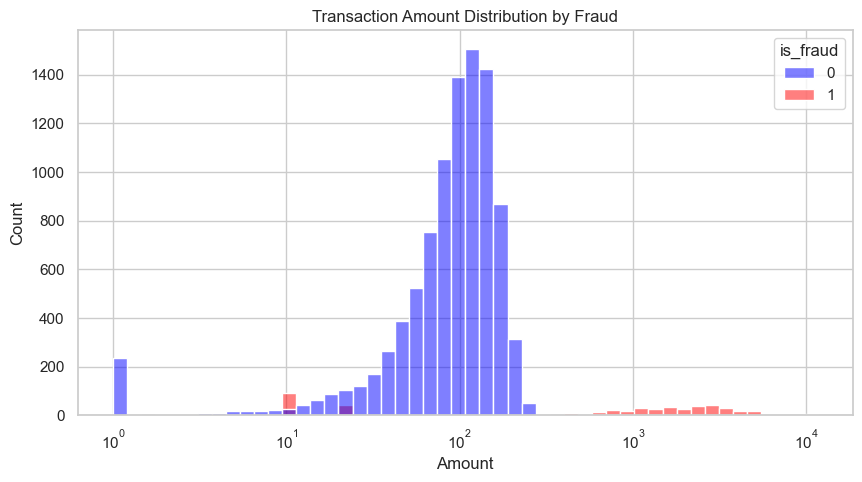

In [86]:
# Amount distribution by fraud
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='amount', hue='is_fraud', bins=50, log_scale=True, palette=['blue','red'])
plt.title("Transaction Amount Distribution by Fraud")
plt.xlabel("Amount")
plt.ylabel("Count")
plt.show()

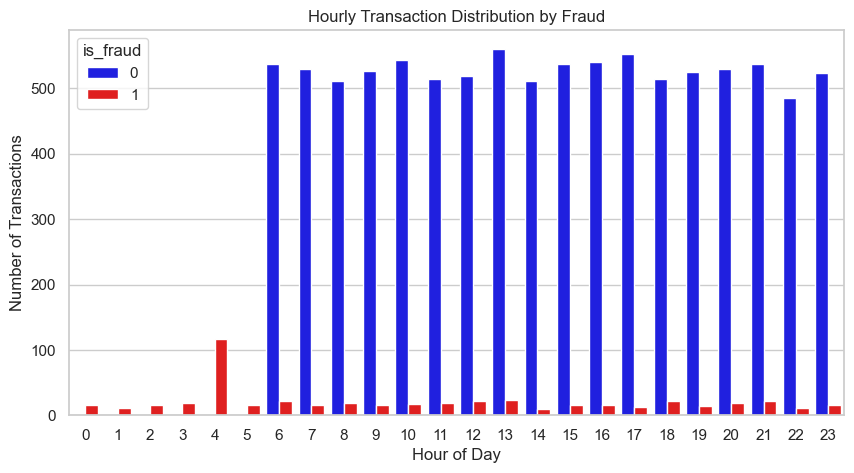

In [87]:
# Count of transactions per hour by fraud
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='hour', hue='is_fraud', palette=['blue','red'])
plt.title("Hourly Transaction Distribution by Fraud")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.show()

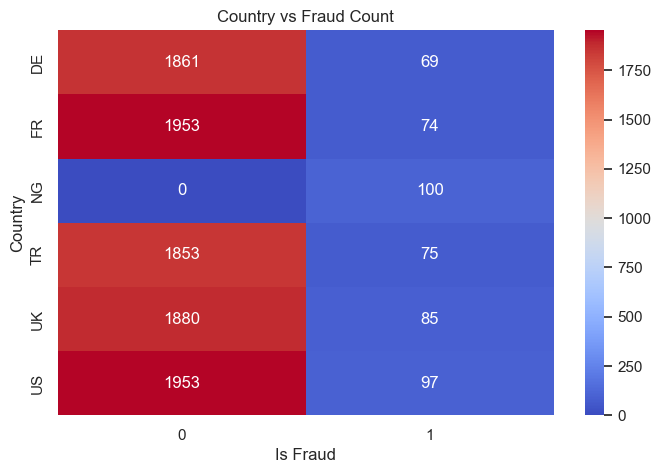

In [88]:
# Pivot table: country vs fraud
country_fraud = df.pivot_table(index='country', columns='is_fraud', values='transaction_id', aggfunc='count').fillna(0)

# Plot heatmap
plt.figure(figsize=(8,5))
sns.heatmap(country_fraud, annot=True, fmt='g', cmap='coolwarm')
plt.title("Country vs Fraud Count")
plt.xlabel("Is Fraud")
plt.ylabel("Country")
plt.show()